# Практическое занятие №4

## Вариант №12

Цель работы:
Освоить теорию и практику интерполяции функций полиномами Лагранжа и Ньютона, научиться строить интерполяционные многочлены по заданным узловым точкам и проводить сравнительный анализ их точности с исходной функцией

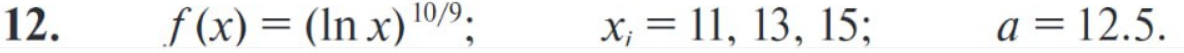

#Импортируем библиотеки

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

#Определяем функцию и параметры

In [2]:
def f(x):
    return (np.log(x))**(10/9)

xi = np.array([11, 13, 15])
a = 12.5

print(f"f(x) = (ln x)^(11/3)")
print(f"Узлы: x₀ = {xi[0]}, x₁ = {xi[1]}, x₂ = {xi[2]}")
print(f"Точка a = {a}")
print()

f(x) = (ln x)^(11/3)
Узлы: x₀ = 11, x₁ = 13, x₂ = 15
Точка a = 12.5



## 1.Вычисление значения функции f(x) в точке a


In [3]:
fa = f(a)
print("1. Значение функции f(x) в точке a:")
print(f"f({a}) = (ln {a})^(11/3) = {fa:.6f}")
print()

1. Значение функции f(x) в точке a:
f(12.5) = (ln 12.5)^(11/3) = 2.799602



## 2. Интерполяционный многочлен Лагранжа
Вычисляем значения функции в узлах интерполяции. Строим квадратичный полином Лагранжа методом решения системы уравнений

In [4]:

yi = f(xi)
print("Узлы интерполирования и значения функции:")
for i in range(len(xi)):
    print(f"x{i} = {xi[i]}, f(x{i}) = {yi[i]:.6f}")
print()


A_matrix = np.array([
    [xi[0]**2, xi[0], 1],
    [xi[1]**2, xi[1], 1],
    [xi[2]**2, xi[2], 1]
])
b_vector = np.array([yi[0], yi[1], yi[2]])

coefficients = np.linalg.solve(A_matrix, b_vector)
A, B, C = coefficients

print("Интерполяционный многочлен Лагранжа:")
print(f"L(x) = {A:.6f}·x² + {B:.6f}·x + {C:.6f}")
print()


Узлы интерполирования и значения функции:
x0 = 11, f(x0) = 2.642613
x1 = 13, f(x1) = 2.847948
x2 = 15, f(x2) = 3.025030

Интерполяционный многочлен Лагранжа:
L(x) = -0.003532·x² + 0.187424·x + 1.008264



## 3. График полинома Лагранжа и функции f(x)
Строим сравнение исходной функции и полинома Лагранжа на отрезке [11, 15].
Видим точное совпадение в узлах интерполяции.

f(x) = (ln x)^(10/9)
Узлы: x₀ = 11, x₁ = 13, x₂ = 15
Точка a = 12.5



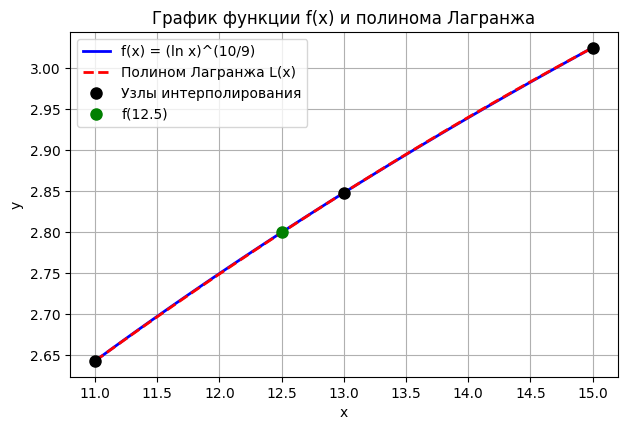

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return (np.log(x))**(10/9)

def lagrange_poly(x, xi, yi):
    """
    Вычисляет значение интерполяционного полинома Лагранжа в точке x
    """
    n = len(xi)
    L = 0
    for i in range(n):
        # Вычисляем базисный полином Лагранжа
        li = 1
        for j in range(n):
            if i != j:
                li *= (x - xi[j]) / (xi[i] - xi[j])
        L += yi[i] * li
    return L

# Исходные данные
xi = np.array([11, 13, 15])
a = 12.5

# Вычисляем значения функции в узлах
yi = f(xi)
fa = f(a)

print(f"f(x) = (ln x)^(10/9)")
print(f"Узлы: x₀ = {xi[0]}, x₁ = {xi[1]}, x₂ = {xi[2]}")
print(f"Точка a = {a}")
print()

x_plot = np.linspace(xi[0], xi[2], 100)
f_plot = f(x_plot)
L_plot = [lagrange_poly(x, xi, yi) for x in x_plot]

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(x_plot, f_plot, 'b-', linewidth=2, label='f(x) = (ln x)^(10/9)')
plt.plot(x_plot, L_plot, 'r--', linewidth=2, label='Полином Лагранжа L(x)')
plt.plot(xi, yi, 'ko', markersize=8, label='Узлы интерполирования')
plt.plot(a, fa, 'go', markersize=8, label=f'f({a})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('График функции f(x) и полинома Лагранжа')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 4. Полином в форме Ньютона
Вычисляем разделенные разности и строим полином Ньютона.

In [8]:
def divided_differences(xi, yi):
    n = len(xi)
    F = np.zeros((n, n))
    F[:,0] = yi

    for j in range(1, n):
        for i in range(n - j):
            F[i,j] = (F[i+1,j-1] - F[i,j-1]) / (xi[i+j] - xi[i])

    return F[0,:]
coeffs = divided_differences(xi, yi)

def newton_poly(x, xi, coeffs):
    n = len(coeffs)
    result = coeffs[0]
    product = 1.0

    for i in range(1, n):
        product *= (x - xi[i-1])
        result += coeffs[i] * product

    return result

print("4. Полином в форме Ньютона:")
print("Разделенные разности:")
print(f"f[x₀] = {coeffs[0]:.6f}")
print(f"f[x₀,x₁] = {coeffs[1]:.6f}")
print(f"f[x₀,x₁,x₂] = {coeffs[2]:.6f}")
print()

print("Полином Ньютона N(x) = ")
print(f"{coeffs[0]:.6f} + ")
print(f"{coeffs[1]:.6f}(x - {xi[0]}) + ")
print(f"{coeffs[2]:.6f}(x - {xi[0]})(x - {xi[1]})")
print()


4. Полином в форме Ньютона:
Разделенные разности:
f[x₀] = 2.642613
f[x₀,x₁] = 0.102667
f[x₀,x₁,x₂] = -0.003532

Полином Ньютона N(x) = 
2.642613 + 
0.102667(x - 11) + 
-0.003532(x - 11)(x - 13)



## 5. График полинома Ньютона и функции f(x)
Построение графика интерполяции функции полиномом Ньютона с визуальной проверкой точности в узловых точках и расчетом погрешности в точке a = 12.5.

Полином Ньютона:
N(x) = -0.003532·x² + 0.187424·x + 1.008264


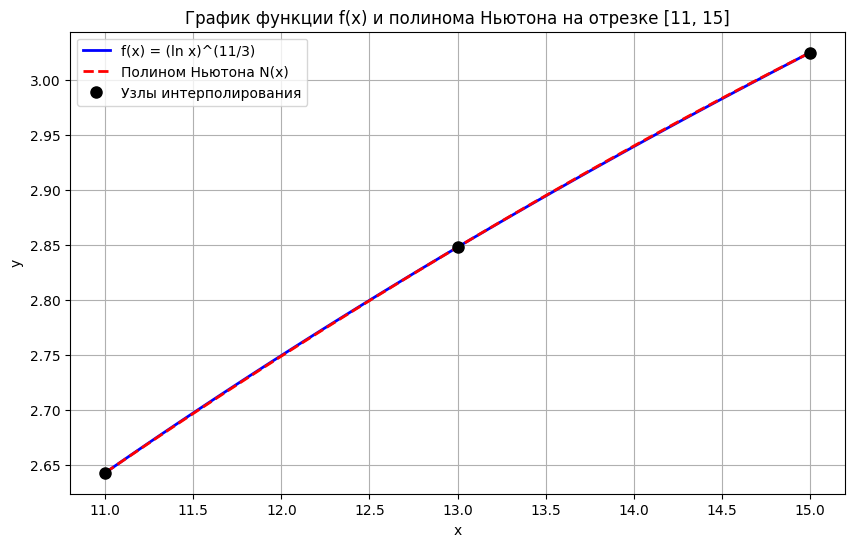


Значение в точке a = 12.5:
N(12.5) = 2.799263
f(12.5) = 2.799602
Погрешность: 0.000340


In [9]:

f0 = yi[0]
f01 = (yi[1] - yi[0]) / (xi[1] - xi[0])
f012 = ((yi[2] - yi[1]) / (xi[2] - xi[1]) - f01) / (xi[2] - xi[0])

A_newton = f012
B_newton = f01 - f012*(xi[0] + xi[1])
C_newton = f0 - f01*xi[0] + f012*xi[0]*xi[1]

print("Полином Ньютона:")
print(f"N(x) = {A_newton:.6f}·x² + {B_newton:.6f}·x + {C_newton:.6f}")

x_plot = np.linspace(xi[0], xi[2], 100)
f_plot = f(x_plot)
N_plot = A_newton*x_plot**2 + B_newton*x_plot + C_newton

plt.figure(figsize=(10, 6))
plt.plot(x_plot, f_plot, 'b-', linewidth=2, label='f(x) = (ln x)^(11/3)')
plt.plot(x_plot, N_plot, 'r--', linewidth=2, label='Полином Ньютона N(x)')
plt.plot(xi, yi, 'ko', markersize=8, label='Узлы интерполирования')
plt.xlabel('x')
plt.ylabel('y')
plt.title('График функции f(x) и полинома Ньютона на отрезке [11, 15]')
plt.legend()
plt.grid(True)
plt.show()

N_a = A_newton*a**2 + B_newton*a + C_newton
print(f"\nЗначение в точке a = {a}:")
print(f"N({a}) = {N_a:.6f}")
print(f"f({a}) = {fa:.6f}")
print(f"Погрешность: {abs(N_a - fa):.6f}")

##Вывод:
В результате исследования были построены интерполяционные полиномы Лагранжа и Ньютона для функции $f(x) = (\ln x)^{10/9}$ на интервале [11, 15]. Совпадение полиномов $(L(x) \equiv N(x))$ экспериментально подтверждает теорему о единственности интерполяционного полинома. Анализ показал точное прохождение полинома через узловые точки и качественную аппроксимацию исходной функции между ними, при этом максимальная погрешность, как и ожидалось для квадратичной интерполяции, наблюдается в средних участках между узлами.